In [1]:
# To align the tables to the left
from IPython.core.display import HTML
table_css = "table {align:left;display:block}"
HTML(f"<style>{table_css}</style>")

# Problem Statement
The following data about size vs price of houses is given:
| Size (1000 sqft)    | Price (1000s of dollars) |
| ------------------- | ------------------------ |
| 1.0                 | 300                      |
| 2.0                 | 500                      |

Find the price of a 1200 sqft house using a linear regression model.

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [3]:
x_train = np.array([1.0, 2.0])
y_train = np.array([300.0, 500.0])

In [4]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost_sum = 0

    for i in range(m):
        f_wb = w * x[i] + b
        loss = (f_wb - y[i]) ** 2
        cost_sum += loss

    total_cost = cost_sum / (2 * m)
    return total_cost

In [5]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dJ_dw = 0
    dJ_db = 0

    for i in range(m):
        f_wb = w * x[i] + b
        dJ_dw_i = (f_wb - y[i]) * x[i]
        dJ_db_i = f_wb - y[i]
        dJ_dw += dJ_dw_i
        dJ_db += dJ_db_i

    dJ_dw /= m
    dJ_db /= m
    return dJ_dw, dJ_db

In [6]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
    J_history = []
    p_history = []
    w = w_in
    b = b_in

    for i in range(num_iters):
        dJ_dw, dJ_db = gradient_function(x, y, w, b)
        w -= alpha * dJ_dw
        b -= alpha * dJ_db

        if i < 100000:
            J_history.append(cost_function(x, y, w, b))
            p_history.append([w, b])

        if i % math.ceil(num_iters / 10) == 0:
            print(
                f"Iteration {i:5d}: "
                f"Cost {J_history[-1]:12.2e}  "
                f"dJ_dw: {dJ_dw:12.3e}, "
                f"dJ_db: {dJ_db:12.3e}   "
                f"w: {w:12.3e}, "
                f"b: {b:12.5e}"
            )

    return w, b, J_history, p_history

In [7]:
w_init = 0
b_init = 0
iterations = 10000
tmp_alpha = 1.0e-2
w_final, b_final, J_hist, p_hist = gradient_descent(x_train, y_train, w_init, b_init, tmp_alpha, iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration     0: Cost     7.93e+04  dJ_dw:   -6.500e+02, dJ_db:   -4.000e+02   w:    6.500e+00, b:  4.00000e+00
Iteration  1000: Cost     3.41e+00  dJ_dw:   -3.712e-01, dJ_db:    6.007e-01   w:    1.949e+02, b:  1.08228e+02
Iteration  2000: Cost     7.93e-01  dJ_dw:   -1.789e-01, dJ_db:    2.895e-01   w:    1.975e+02, b:  1.03966e+02
Iteration  3000: Cost     1.84e-01  dJ_dw:   -8.625e-02, dJ_db:    1.396e-01   w:    1.988e+02, b:  1.01912e+02
Iteration  4000: Cost     4.28e-02  dJ_dw:   -4.158e-02, dJ_db:    6.727e-02   w:    1.994e+02, b:  1.00922e+02
Iteration  5000: Cost     9.95e-03  dJ_dw:   -2.004e-02, dJ_db:    3.243e-02   w:    1.997e+02, b:  1.00444e+02
Iteration  6000: Cost     2.31e-03  dJ_dw:   -9.660e-03, dJ_db:    1.563e-02   w:    1.999e+02, b:  1.00214e+02
Iteration  7000: Cost     5.37e-04  dJ_dw:   -4.657e-03, dJ_db:    7.535e-03   w:    1.999e+02, b:  1.00103e+02
Iteration  8000: Cost     1.25e-04  dJ_dw:   -2.245e-03, dJ_db:    3.632e-03   w:    2.000e+02, b:  1.00

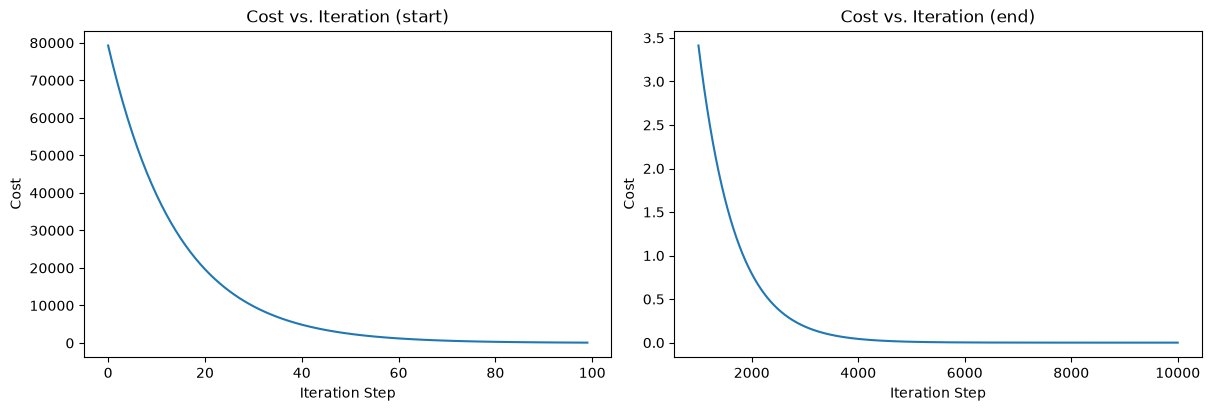

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title("Cost vs. Iteration (start)")
ax2.set_title("Cost vs. Iteration (end)")
ax1.set_ylabel("Cost")
ax2.set_ylabel("Cost")
ax1.set_xlabel("Iteration Step")
ax2.set_xlabel("Iteration Step")
plt.show()

In [9]:
print(f"1000 sqft house prediction {w_final * 1.0 + b_final:0.1f} Thousand dollars")
print(f"1200 sqft house prediction {w_final * 1.2 + b_final:0.1f} Thousand dollars")
print(f"2000 sqft house prediction {w_final * 2.0 + b_final:0.1f} Thousand dollars")

1000 sqft house prediction 300.0 Thousand dollars
1200 sqft house prediction 340.0 Thousand dollars
2000 sqft house prediction 500.0 Thousand dollars


In [10]:
w_init = 0
b_init = 0
iterations = 10
tmp_alpha = 8.0e-1
w_final, b_final, J_hist, p_hist = gradient_descent(x_train, y_train, w_init, b_init, tmp_alpha, iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration     0: Cost     2.58e+05  dJ_dw:   -6.500e+02, dJ_db:   -4.000e+02   w:    5.200e+02, b:  3.20000e+02
Iteration     1: Cost     7.82e+05  dJ_dw:    1.130e+03, dJ_db:    7.000e+02   w:   -3.840e+02, b: -2.40000e+02
Iteration     2: Cost     2.37e+06  dJ_dw:   -1.970e+03, dJ_db:   -1.216e+03   w:    1.192e+03, b:  7.32800e+02
Iteration     3: Cost     7.19e+06  dJ_dw:    3.429e+03, dJ_db:    2.121e+03   w:   -1.551e+03, b: -9.63840e+02
Iteration     4: Cost     2.18e+07  dJ_dw:   -5.974e+03, dJ_db:   -3.691e+03   w:    3.228e+03, b:  1.98886e+03
Iteration     5: Cost     6.62e+07  dJ_dw:    1.040e+04, dJ_db:    6.431e+03   w:   -5.095e+03, b: -3.15579e+03
Iteration     6: Cost     2.01e+08  dJ_dw:   -1.812e+04, dJ_db:   -1.120e+04   w:    9.402e+03, b:  5.80237e+03
Iteration     7: Cost     6.09e+08  dJ_dw:    3.156e+04, dJ_db:    1.950e+04   w:   -1.584e+04, b: -9.80139e+03
Iteration     8: Cost     1.85e+09  dJ_dw:   -5.496e+04, dJ_db:   -3.397e+04   w:    2.813e+04, b:  1.73

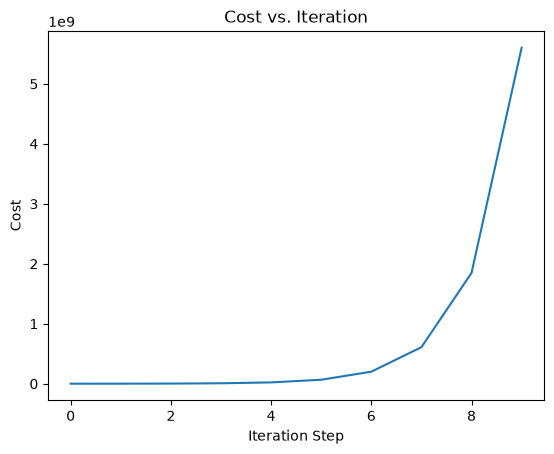

In [11]:
plt.plot(J_hist[:10])
plt.title("Cost vs. Iteration")
plt.ylabel("Cost")
plt.xlabel("Iteration Step")
plt.show()